In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Data collection

In [2]:
''' I downloaded a ready-made dataset from Kaggle that meets the project requirements.'''

co2_emissions_dataSet = pd.read_csv("Sample (1).csv")
co2_emissions_dataSet

,MODEL,MAKE,MODEL.1,VEHICLE CLASS,ENGINE_SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL_CONSUMPTION*,Unnamed: 9,Unnamed: 10,Unnamed: 11,CO2_EMISSIONS
0,2001,ACURA,1.7EL,COMPACT,1.7,4,A4,X,9.3,7.2,8.3,34,191
1,2001,ACURA,1.7EL,COMPACT,1.7,4,M5,X,8.9,7.4,8.3,34,191
2,2001,ACURA,3.2CL,COMPACT,3.2,6,AS5,Z,13.7,8.8,11.5,25,265
3,2001,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,13.8,8.8,11.6,24,267
4,2001,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,15.0,10.9,13.1,22,301
...,...,...,...,...,...,...,...,...,...,...,...,...,...
674,2001,VOLVO,V70 T5 WAGON TURBO,STATION WAGON - MID-SIZE,2.3,5,M5,Z,13.0,9.3,11.3,25,260
675,2001,VOLVO,V70 WAGON,STATION WAGON - MID-SIZE,2.4,5,A5,Z,12.8,9.3,11.2,25,258
676,2001,VOLVO,V70 WAGON,STATION WAGON - MID-SIZE,2.4,5,M5,Z,12.5,9.3,11.0,26,253
677,2001,VOLVO,V70 WAGON AWD TURBO,STATION WAGON - MID-SIZE,2.4,5,AS5,Z,14.4,10.3,12.5,23,288


In [3]:
selected_data = ['ENGINE_SIZE', 'FUEL_CONSUMPTION*', 'CO2_EMISSIONS']
co2_emissions_df = co2_emissions_dataSet[selected_data]
co2_emissions_df

,ENGINE_SIZE,FUEL_CONSUMPTION*,CO2_EMISSIONS
0,1.7,9.3,191
1,1.7,8.9,191
2,3.2,13.7,265
3,3.2,13.8,267
4,3.5,15.0,301
...,...,...,...
674,2.3,13.0,260
675,2.4,12.8,258
676,2.4,12.5,253
677,2.4,14.4,288


# 2. Analysis of features' relationships with Co2 emissions

Text(0.5, 1.0, 'CO2_EMISSIONS vs ENGINE_SIZE')

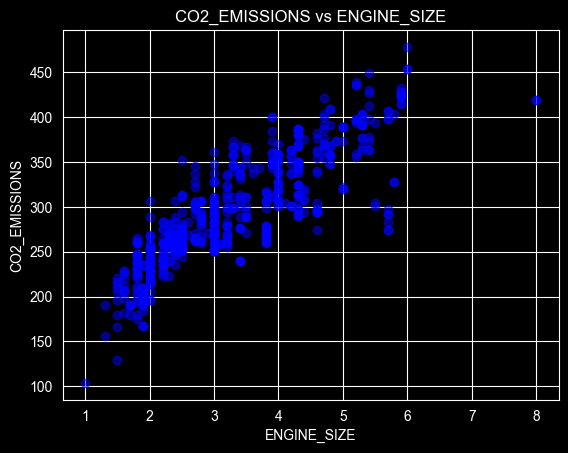

In [4]:
plt.scatter(co2_emissions_df["ENGINE_SIZE"], co2_emissions_df["CO2_EMISSIONS"], color="blue", alpha=0.5)
plt.xlabel("ENGINE_SIZE")
plt.ylabel("CO2_EMISSIONS")
plt.title("CO2_EMISSIONS vs ENGINE_SIZE")

Text(0.5, 1.0, 'CO2_EMISSIONS vs FUEL_CONSUMPTION')

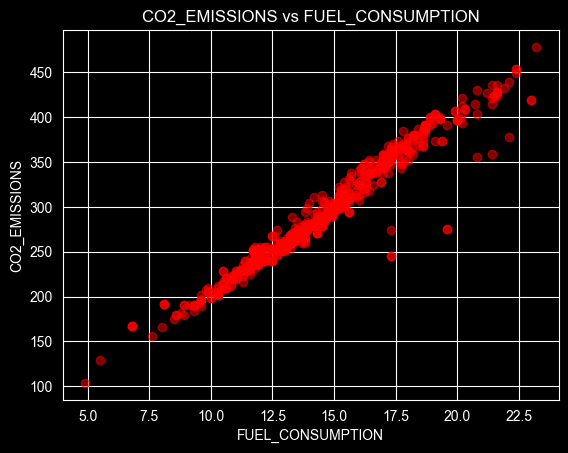

In [5]:
plt.scatter(co2_emissions_df["FUEL_CONSUMPTION*"], co2_emissions_df["CO2_EMISSIONS"], color="red", alpha=0.5)
plt.xlabel("FUEL_CONSUMPTION")
plt.ylabel("CO2_EMISSIONS")
plt.title("CO2_EMISSIONS vs FUEL_CONSUMPTION")

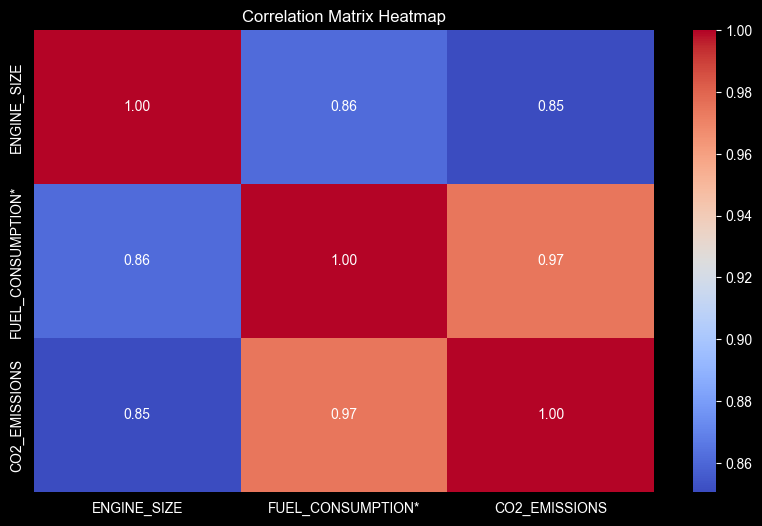

In [6]:
''' heat map of all features '''
plt.figure(figsize=(10,6))
correlation_matrix = co2_emissions_df.corr()
sns.heatmap(correlation_matrix,cmap="coolwarm",fmt=".2f", annot=True)
plt.title("Correlation Matrix Heatmap")
plt.show()

# 3.Preparing the data

In [7]:
X = co2_emissions_df[['ENGINE_SIZE', 'FUEL_CONSUMPTION*']]
Y = co2_emissions_df['CO2_EMISSIONS']

In [8]:
X

,ENGINE_SIZE,FUEL_CONSUMPTION*
0,1.7,9.3
1,1.7,8.9
2,3.2,13.7
3,3.2,13.8
4,3.5,15.0
...,...,...
674,2.3,13.0
675,2.4,12.8
676,2.4,12.5
677,2.4,14.4


In [9]:
Y

0      191
1      191
2      265
3      267
4      301
      ... 
674    260
675    258
676    253
677    288
678    306
Name: CO2_EMISSIONS, Length: 679, dtype: int64

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 4. training model

In [12]:
model = LinearRegression()
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# 5. make prediction

In [21]:
Y_pred = model.predict(X_test)

In [22]:
print("Comparison of Actual vs Predicted Co2 emissions")
for actual, predicted in list(zip(Y_test[:10], Y_pred[:10])):
    print(f"actual: {round(actual,2)} | predicted: {round(predicted,2)}")


Comparison of Actual vs Predicted Co2 emissions
actual: 237 | predicted: 240.74
actual: 260 | predicted: 267.21
actual: 308 | predicted: 311.08
actual: 359 | predicted: 345.82
actual: 391 | predicted: 375.09
actual: 294 | predicted: 300.24
actual: 354 | predicted: 345.56
actual: 265 | predicted: 270.56
actual: 202 | predicted: 197.06
actual: 370 | predicted: 368.5


In [17]:
print("MSE:", mean_squared_error(Y_test, Y_pred))
print("R2 :", r2_score(Y_test, Y_pred))

MSE: 169.14500919402138
R2 : 0.9505206864793785


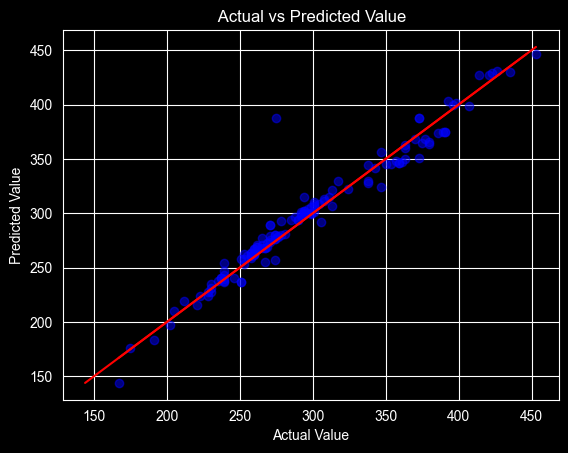

In [20]:
plt.scatter(Y_test, Y_pred, color="blue", alpha=0.5)

min_val = [Y_test.min(), Y_pred.min()]
max_val = [Y_test.max(), Y_pred.max()]

plt.plot([min_val, max_val], [min_val, max_val], color="red")
plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title(" Actual vs Predicted Value")
plt.show()